# Markov-Switching AR Model

This presents the implementation and validation results of the Markov-Switching AR model for both return forecasting and realized-volatility forecasting on SPY.

In [1]:
from model_utils import MSARConfig, run_full_msar_pipeline, plot_regime_probabilities
import pandas as pd

/Users/raceee-g/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
config = MSARConfig(
    ticker="SPY",
    start_date="2019-01-01",
    end_date="2025-01-01",
    train_ratio=0.7,
    val_ratio=0.15,
    k_regimes=2,
    order=1,
    trend="c",
    rv_window=5,
)

outputs_return = run_full_msar_pipeline(config, target_col="return")
outputs_rv = run_full_msar_pipeline(config, target_col="log_rv")

Loading data from cache...
Loading data from cache...


## Return Prediction: Best Model Configuration

In [3]:
outputs_return["best_config"]

{'k_regimes': 2,
 'order': 1,
 'switching_variance': True,
 'trend': 'c',
 'switching_ar': False}

## Return Prediction: Hyperparameter Tuning Results

In [4]:
outputs_return["tuning_table"]

,k_regimes,order,switching_variance,aic,bic,llf,error
0,2,1,True,-6434.024477,-6399.315338,3224.012238,None
1,2,2,True,-6427.572270,-6387.912291,3221.786135,None
2,2,1,False,-6127.246843,-6097.496152,3069.623421,None
3,2,2,False,-6006.788175,-5972.085694,3010.394088,None


## Return Prediction: Validation Metrics

In [5]:
outputs_return["validation_metrics"]

{'MSE': 5.733694275777382e-05,
 'MAE': 0.005959213766283605,
 'RMSE': 0.007572116134725736,
 'Directional_Accuracy': 0.5530973451327433}

## Return Prediction: Forecast Comparison

<Axes: title={'center': 'Actual vs Predicted SPY Returns'}>

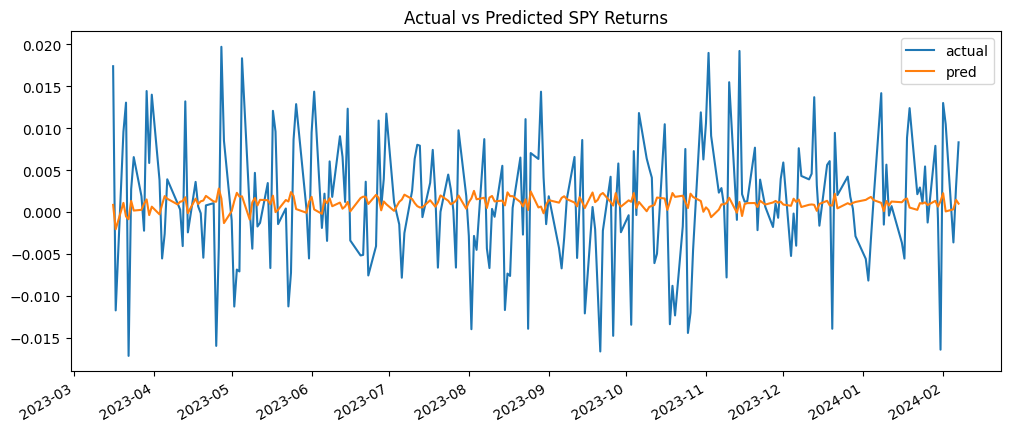

In [6]:
outputs_return["validation_forecasts"][["actual", "pred"]].plot(
    figsize=(12, 5),
    title="Actual vs Predicted SPY Returns"
)

## Return Prediction: Regime Probabilities

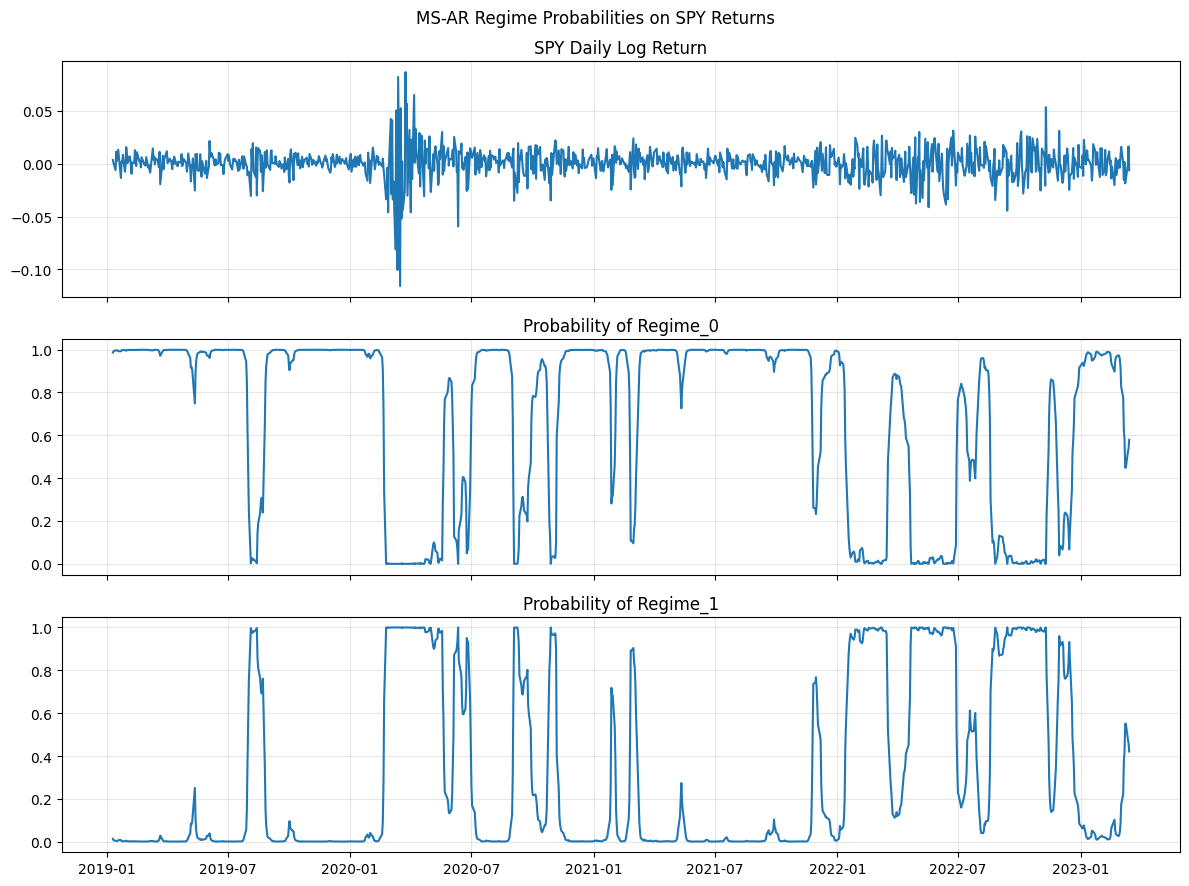

In [7]:
plot_regime_probabilities(
    outputs_return["best_result"],
    outputs_return["train"]["return"],
    title="MS-AR Regime Probabilities on SPY Returns",
    target_label="SPY Daily Log Return",
)

## Return Prediction: Regime Quality Metrics

In [15]:
print("Persistence metrics:")
print(outputs_return["regime_persistence_metrics"])

print("\nInterpretability metrics:")
print(outputs_return["regime_interpretability_metrics"])

print("\nStress alignment metrics:")
print(outputs_return["regime_stress_alignment_metrics"])

Persistence metrics:
   regime     p_ii  expected_duration
0       0  0.97772          44.884170
1       1  0.95070          20.284008

Interpretability metrics:
   regime  target  n_obs  mean_target  std_target
0       0  return    730     0.001438    0.007489
1       1  return    322    -0.001775    0.022677

Stress alignment metrics:
{'high_vol_regime': 'Regime_0', 'avg_prob_high_vol_regime_on_drawdown_days': 0.25215798882130497, 'avg_prob_high_vol_regime_on_high_vol_days': 0.1226564150396412}


## Realized Volatility Prediction: Best Model Configuration

In [16]:
outputs_rv["best_config"]

{'k_regimes': 2,
 'order': 2,
 'switching_variance': True,
 'trend': 'c',
 'switching_ar': False}

## Realized Volatility Prediction: Hyperparameter Tuning Results

In [17]:
outputs_rv["tuning_table"]

,k_regimes,order,switching_variance,aic,bic,llf,error
0,2,2,True,182.398113,222.058092,-83.199057,None
1,2,1,False,238.104800,267.855490,-113.052400,None
2,2,1,True,233.622367,268.331506,-109.811184,None
3,2,2,False,236.053935,270.756417,-111.026968,None


## Realized Volatility Prediction: Validation Metrics

In [18]:
outputs_rv["validation_metrics"]

{'MSE': 16.926374382918016,
 'MAE': 4.1045637803634545,
 'RMSE': 4.11416752003586}

## Realized Volatility Prediction: Forecast Comparison

<Axes: title={'center': 'Actual vs Predicted SPY Log Realized Volatility'}>

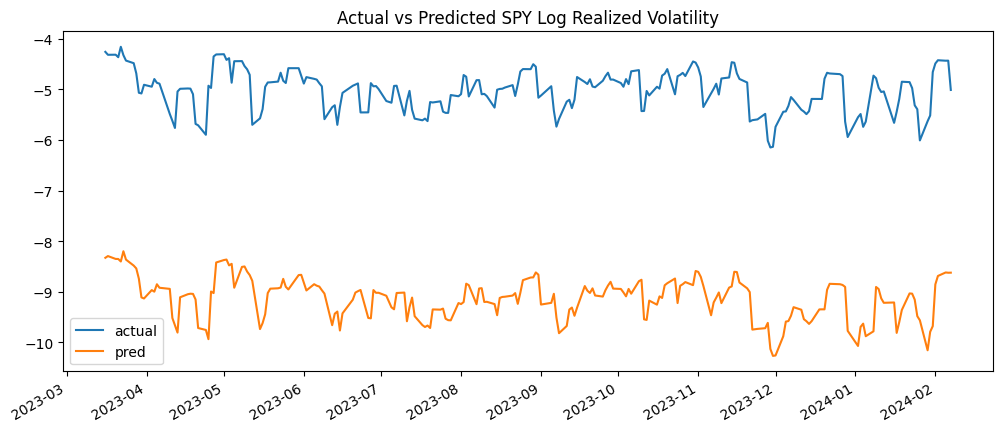

In [12]:
outputs_rv["validation_forecasts"][["actual", "pred"]].plot(
    figsize=(12, 5),
    title="Actual vs Predicted SPY Log Realized Volatility"
)

## Realized Volatility Prediction: Regime Probabilities

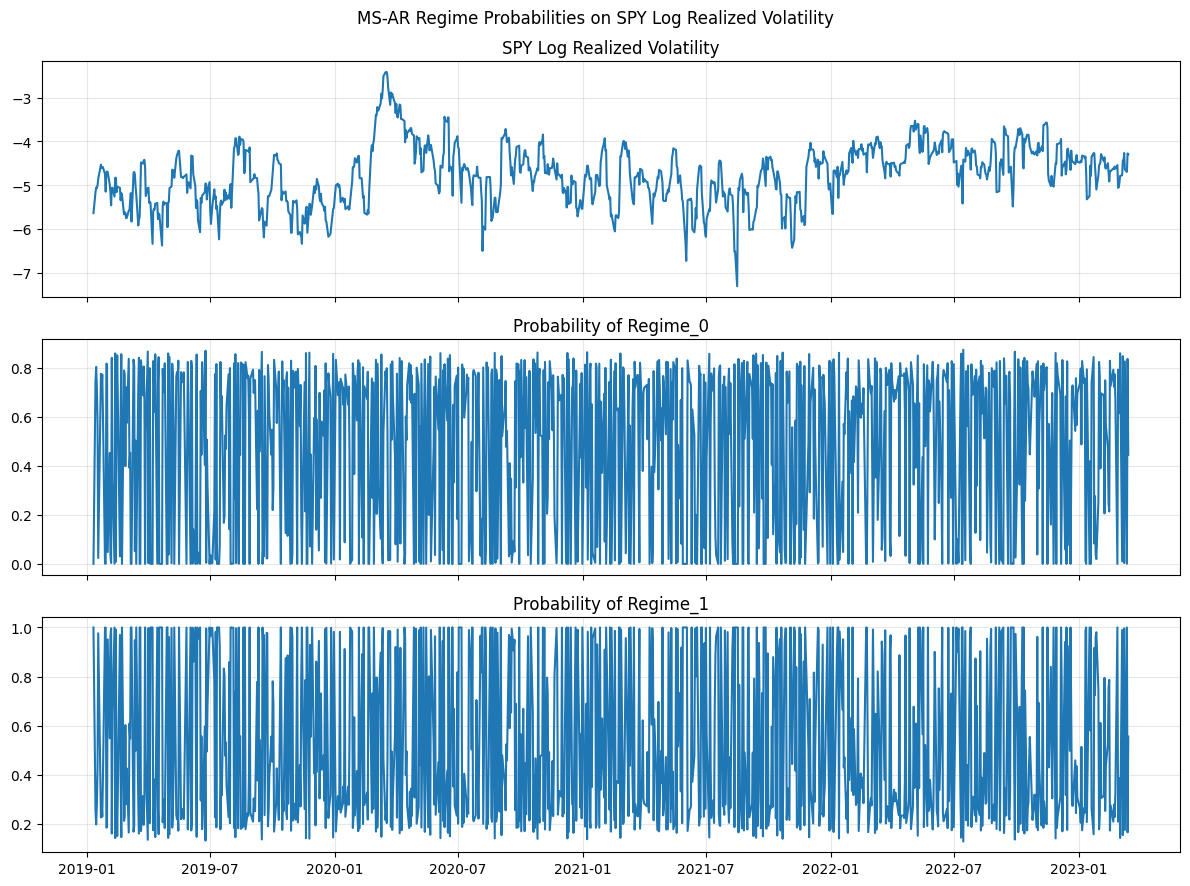

In [13]:
plot_regime_probabilities(
    outputs_rv["best_result"],
    outputs_rv["train"]["log_rv"],
    title="MS-AR Regime Probabilities on SPY Log Realized Volatility",
    target_label="SPY Log Realized Volatility",
)

## Realized Volatility Prediction: Regime Quality Metrics

In [14]:
print("Persistence metrics:")
print(outputs_rv["regime_persistence_metrics"])
print("
Interpretability metrics:")
print(outputs_rv["regime_interpretability_metrics"])
print("
Stress alignment metrics:")
print(outputs_rv["regime_stress_alignment_metrics"])

SyntaxError: unterminated string literal (detected at line 3) (4270686468.py, line 3)

## Return vs Realized Volatility Comparison

In [ ]:
comparison = pd.DataFrame({
    "Return MS-AR": outputs_return["validation_metrics"],
    "Log RV MS-AR": outputs_rv["validation_metrics"],
})
comparison

## Conclusion

The return-based MS-AR model tests whether regime switching improves short-horizon return predictability. Because equity index returns have weak serial dependence, return forecasting remains difficult. The realized-volatility version uses log realized volatility as the prediction target and is more directly aligned with regime identification. This second specification is expected to produce clearer low-volatility and high-volatility states, making it useful for interpreting market conditions even when return predictability is limited.